## Spatial Data Science (GIS6307/GEO4930)

---

# Lab 7: Spatial Data Conversion

In this lab, you will use spatial analysis tools to convert data in different formats. Specifically, the following methods will be used:
- **Zonal operation**: aggregate raster data in polygons
- **Spatial and attribute join**: join (geo)dataframes based on spatial and attribute relations.
- **Spatial interpolation**: estimate spatial attributes from sampled points.

### `Due on Monday 4/18. Submit the completed Jupyter Notebook (.ipynb) in Canvas`

<br>
Instructor: Yi Qiang (qiangy@usf.edu)<br>
Teaching Assistant: Jinwen Xu (jinwenxu@usf.edu)


# Exercise 1: Zonal Operation

Zonal operation is a often used method to aggregate raster pixels into discrete zones (e.g. polygons). In this task, we will use zonal statistics to calculate urban ratio (urban area/total area) in census tracts to find out the most urbanized neighborhoods in Oahu.

## 1.1: Reading and Exploring Data

First, please open an Anaconda Prompt, activate the `geo` environment and install a new library `rasterstats` using the following command:

`conda install -c conda-forge rasterstats`

Next, please import the following libraries.

In [ ]:
import pandas as pd
import geopandas as gpd
import rasterio
import rasterio.plot as rio_pl
import matplotlib.pyplot as plt
import numpy as np

#set default plot size, you can adjust the [width, height] to make plots fit your screen size
plt.rcParams['figure.figsize'] = [12, 10]
plt.figure(figsize = (12,10))

Read the land cover data data (raster) and census tract boundaries (polygons) in Oahu, HI.

In [ ]:
# read the shapefile as a geodataframe ct.
ct = gpd.read_file("other/CensusTract_Oahu.shp")

# read the land cover data into lc
lc = rasterio.open("other/hi_oahu_2011_ccap_hr_land_cover20140619.img")

Plot the land cover data and census tracts in two maps (subplots) side by side.

In [ ]:
# Create a plot canvas with two subplots in a row
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize=(15,10))

# Plot the polygons in ct in ax2
ct.plot(ax=ax2, facecolor='None',edgecolor = 'black', linewidth=1)

# Use rasterio.show to plot the land cover in ax1
rio_pl.show((lc, 1), ax=ax1)

Before zonal operation, the two map layers (land cover and census tracts) need to be projected to the same coordinate system. First, we print the coordinate systems of the two datasets. You can see the land cover data is in UTM zone 4N (EPSG: 32604) and the census tracts is in the geographic coordinate system (EPSG: 7030).

In [ ]:
print("CRS of the land cover data: " + str(lc.crs))

print("CRS of the census tract polygons: " + str(ct.crs))

> Tip: The epsg numbers are the unique IDs of coordinate systems. You search the specific coordinate systems using the epsg numbers in [https://www.epsg-registry.org/](https://www.epsg-registry.org/).

We will convert the coordinate system of `ct` to UTM zone 4N, to be the same as the CRS of the land cover raster.

Usually, it's recommended to convert the coordinate system of the vector instead of raster. Converting the coordinate system of raster data will go through resampling, causing extra bias and uncertainties.

In [ ]:
# Converting census tracts to the CRS of land cover data
ct = ct.to_crs(lc.crs)

After coordinate conversion, the two data layers can be plotted in the same map.

In [ ]:
# Create an empty canvas ax3
ax3 = plt.subplot()

# Use rasterio.show to map the land cover data in ax3
rio_pl.show((lc, 1), ax = ax3)

# Plot the census tract boundaries in ax3
ct.plot(ax = ax3, facecolor = 'None', edgecolor = 'white', linewidth = 1)

Next, we will use zonal operation to aggregate urban pixels in the census tracts. 

The line below extracts the 1st band (the only band) of the raster and store it in a numpy array. The extracted array is a 2D matrix of numbers (not spatially projected).

In [ ]:
array = lc.read(1)

Print the unique values in the array. These values represent different land cover type.

In [ ]:
np.unique(array)

These numbers represent different land cover types. The land cover types of these numbers can be found in [here](https://coast.noaa.gov/data/digitalcoast/pdf/ccap-class-scheme-regional.pdf). For instance, 2 stands for "Developed, High Intensity" area. In this task, we consider all developed land types (2-5) as urban area.

In this task, we will calculate the ratios of urban area in different census tracts. The strategy is using zonal operation to count urban pixels (2 - 5) and total pixels (other values) in each census tract. Then, the urban ratio is calculated by dividing urban pixels by total pixels in each census tract.

The code cell below classify the land cover data to binary values (1: urban, 0: non-urban).

In [ ]:
# reclassify all non-urban pixels to 0
array[np.where((array > 5)|(array < 2))] = 0

# reclassify pixels from 2 to 5 to 1.
array[np.where((array >= 2) & (array<=5))] = 1

Plot unique values in the reclassified `array`. 

In [ ]:
np.unique(array)

Plot the reclassified `array` in a map.

In [ ]:
# plot the reclassified raster
plt.imshow(array)

Next, we use zonal operation ('zonal_stats') to aggregate the reclassified binary raster (0: non-urban, 1: urban) into census tracts. In `zonal_stats`: 
- `stats` defines the function(s) of aggregation. Here, the sum (sum of urban pixels) and count (total pixels) are aggregated.
- `affine` defines the origin and cellsize of the raster, which is used to project `array`.

In [ ]:
from rasterstats import zonal_stats
ct_z = zonal_stats(ct, array, affine = lc.transform, stats=['count','sum'])

You can also aggregate pixels using mean, max, min, majority, etc. The complete description of the `zonal_states` function can be found in [https://pythonhosted.org/rasterstats/manual.html#zonal-statistics].

Print `zs_ct` to see what's inside.

In [ ]:
ct_z

convert `zs_ct` from a 2D list to a data frame.

In [ ]:
# convert ct_z to a dataframe ct_z_df
ct_z_df = pd.DataFrame(ct_z)

# preview the data frame
ct_z_df.head()

### Question 1 (1.5pt): Please calculate ratios of urban pixels to total pixels in census tracts, and store the ratios in a new column `urban_ratio` in `ct_z_df`.

> Tip:
> 1. When calculating the ratio, think about which column is the numerator and which is the denominator.
> 2. After calculation, the preview of `ct_z_df` should look like the below figure.

![](https://raw.githubusercontent.com/qiang-yi/spatial_data_science/main/image/wk11/preview.jpg)

In [ ]:
# ......

Next, we will join the urban ratios in `ct_z_df` back to `censustract`. 

As there is no GEOID in `zs_ct_df`, there is no key to do an attribute join of the two tables. As `zs_ct_df` was converted from `zs_ct` (the spatial join output), the row order of `zs_ct_df` is the same as that in `censustract`. Thus, we can horizontally combine `zs_ct_df` with `censustract`. The following figure illustrates horizontal combine of two dataframes

![](https://raw.githubusercontent.com/qiang-yi/spatial_data_science/main/image/wk3/h_concate.jpg)

Horizontally combine `ct` and `ct_z_df` into `ct2`.

In [ ]:
# Horizontally combine ct and ct_z_df to ct2
ct2 = pd.concat([ct, ct_z_df], axis=1, ignore_index= False)

# Preview ct2
ct2.head()

### Question 2 (1.5pt): Create a choropleth map to display the ratios of urban area in census tracts.

> Tips: 
> 1. You can freely choose the color scheme, class number and classification method. 
> 2. Please add a contextily base map in the background.
> 3. You can refer to [Lab 4 (A)](https://github.com/qiang-yi/spatial_data_science/blob/main/Lab4_A_answer.ipynb) for how to create the map.

The map should look like the following one: 

<img src="https://raw.githubusercontent.com/qiang-yi/spatial_data_science/main/image/wk11/Q2.jpg" width="500">


In [ ]:
#......

### Question 3 (2pt): Please calculate forest ratios in the census tracts, and create a choropleth map to display the forest ratios as Question 2.

> Tips:
> 1. Forest are pixels of 9, 10 and 11 in the land cover data
> 2. You need to repeat some of the steps above to count forest pixels in census tracts (`zonal_stats`), convert the result to dataframe and horizontally combine it with `ct`. 

In [ ]:
# ......

---

# Exercise 2: Spatial Join

A spatial join combines two GeoDataFrames based on the spatial relationship (e.g. intersect, within) between their geometries.

A common use case might be a spatial join between a point layer and a polygon layer where you want to aggregate points in the polygons (as illustrated below). This process include three steps: 1) spatial join, 2) aggregation, and 3) attribute join.

![](https://raw.githubusercontent.com/qiang-yi/spatial_data_science/main/image/wk11/points.png)

In this exercise, we will count crimes in census tracts in Oahu.  First, read the crime data in Oahu.

## 2.1 Spatial Join

In [20]:
# Read crime.shp into a geodataframe
crime = gpd.read_file("other/crime.shp")

# Preview crime
crime.head()

,Time,Location,Offence_ty,geometry
0,2018-03-30,911100 BLOCK RENTON RD,PROPERTY DAMAGE,POINT (-158.03614 21.34098)
1,2018-03-30,0 BLOCK KANEOHE BAY DR,DUI,POINT (-157.74857 21.42217)
2,2018-03-30,ALA WAI BLVD&LAUNIU ST,THEFT,POINT (-157.82839 21.28389)
3,2018-03-30,2200 BLOCK KALAKAUA AVE,THEFT,POINT (-157.82952 21.28011)
4,2018-03-30,2200 BLOCK N KING ST,DUI,POINT (-157.88045 21.33548)


Plot crime locations (points) and census tracts (polygons) in two maps side by side.

<AxesSubplot:>

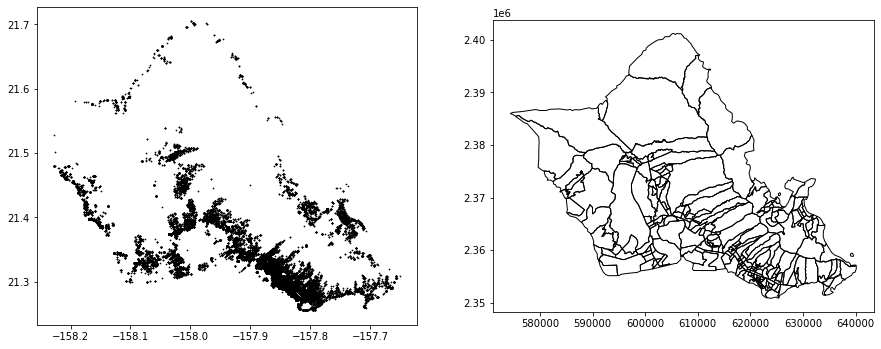

In [21]:
# Create a plot canvas with two subplots in a row
fig, (ax6, ax7) = plt.subplots(nrows = 1, ncols = 2, figsize=(15,10))

# Use rasterio.show to plot the land cover in ax1
crime.plot(ax = ax6, markersize = 0.5, c = 'black')

# Plot the polygons in ct in ax2
ct.plot(ax=ax7, facecolor='None', linewidth=1)

Spatial join requires two datasets in the same coordinate system. Next, we convert the crime points to the coordinate system of census tracts.

In [22]:
crime = crime.to_crs(ct.crs)

Then, we will conduct a spatial join to count the number of crimes in census tracts.

The first step is joinning the crime points (`crime`) in census tracts (`ct`). You can see attributes from `crime` are joined to the table.

> Tip: you can check this [page](https://geopandas.org/en/stable/docs/reference/api/geopandas.sjoin.html) to learn the difference among inner, left and right join.

In [23]:
# Join crime points to ct and save the output in ctj
ct_j = ct.sjoin(crime, how="inner")


# Preview the joined result
ct_j.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,LSAD,ALAND,AWATER,geometry,index_right,Time,Location,Offence_ty
0,15,003,000110,1400000US15003000110,15003000110,1.10,CT,6620520,1030241,"POLYGON ((637054.371 2355554.923, 637091.322 2...",5403,2018-02-19,700 BLOCK KEALAHOU ST,THEFT
0,15,003,000110,1400000US15003000110,15003000110,1.10,CT,6620520,1030241,"POLYGON ((637054.371 2355554.923, 637091.322 2...",9478,2018-01-23,7500 BLOCK NAPOKO PL,UEMV
0,15,003,000110,1400000US15003000110,15003000110,1.10,CT,6620520,1030241,"POLYGON ((637054.371 2355554.923, 637091.322 2...",24224,2017-10-07,KA IWI SHORELINE,UEMV
0,15,003,000110,1400000US15003000110,15003000110,1.10,CT,6620520,1030241,"POLYGON ((637054.371 2355554.923, 637091.322 2...",17614,2017-11-24,7500 BLOCK KAHAKULOA PL,PROPERTY DAMAGE
0,15,003,000110,1400000US15003000110,15003000110,1.10,CT,6620520,1030241,"POLYGON ((637054.371 2355554.923, 637091.322 2...",33735,2017-07-29,KALANIANAOLE HWY&TRAIL MAKAPUU,PROPERTY DAMAGE


Next, we check the number of rows in `ct` and `ct_j`.

You will see that `ct_j` contains much more polygons than `ct`. This is because each polygon-point join is kept a row in `ct_j`. In other words, there are many duplications of identical polygons that are joined to different crimes points.


In [24]:
print("Num of polygons in ct: " + str(len(ct)))
print("Num of polygons in ct_j: " + str(len(ct_j)))

Num of polygons in ct: 243
Num of polygons in ct_j: 49058


## 2.2 Aggregation

Next, we will group the duplicated polygons and keep counts of duplicated polygons in each group. We use the `groupby` function to group the duplicated polygons. However, `groupby` doesn't work on the `geometry` column. So we group `ct_` by the `GEOID` column, which are unique IDs of the polygons.

In [25]:
ct_j2 = ct_j.groupby('GEOID').count().reset_index()

ct_j2.head()

,GEOID,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,NAME,LSAD,ALAND,AWATER,geometry,index_right,Time,Location,Offence_ty
0,15003000106,113,113,113,113,113,113,113,113,113,113,113,113,113
1,15003000107,20,20,20,20,20,20,20,20,20,20,20,20,20
2,15003000108,127,127,127,127,127,127,127,127,127,127,127,127,127
3,15003000110,214,214,214,214,214,214,214,214,214,214,214,214,214
4,15003000111,73,73,73,73,73,73,73,73,73,73,73,73,73


Get only the `GEOID` AND `STATEFP` columns from `ct_j2`.

In [26]:
# Get GEOID and STATEFP
ct_j2 = ct_j2[['GEOID','STATEFP']]

# Rename STATEFP to crime
ct_j2 = ct_j2.rename(columns={"STATEFP": "crime"})

# Preview
ct_j2.head()

,GEOID,crime
0,15003000106,113
1,15003000107,20
2,15003000108,127
3,15003000110,214
4,15003000111,73


## 2.3 Attribute Join

We use `merge` function of dataframe to join `ct_j2` to `ct` using `GEOID` as the key. You can see attributes from both `ct_j2` and `ct` are joined in the same table.

In [28]:
ct_j2 = pd.merge(ct_j2, ct, on ="GEOID")

ct_j2.head()

,GEOID,crime,STATEFP_x,COUNTYFP_x,TRACTCE_x,AFFGEOID_x,NAME_x,LSAD_x,ALAND_x,AWATER_x,geometry_x,STATEFP_y,COUNTYFP_y,TRACTCE_y,AFFGEOID_y,NAME_y,LSAD_y,ALAND_y,AWATER_y,geometry_y
0,15003000106,113,15,003,000106,1400000US15003000106,1.06,CT,7900462,0,"POLYGON ((632384.203 2357905.598, 632455.194 2...",15,003,000106,1400000US15003000106,1.06,CT,7900462,0,"POLYGON ((632384.203 2357905.598, 632455.194 2..."
1,15003000107,20,15,003,000107,1400000US15003000107,1.07,CT,2779744,236436,"POLYGON ((634632.854 2354606.126, 634741.236 2...",15,003,000107,1400000US15003000107,1.07,CT,2779744,236436,"POLYGON ((634632.854 2354606.126, 634741.236 2..."
2,15003000108,127,15,003,000108,1400000US15003000108,1.08,CT,935003,439988,"POLYGON ((632852.065 2354401.726, 632961.482 2...",15,003,000108,1400000US15003000108,1.08,CT,935003,439988,"POLYGON ((632852.065 2354401.726, 632961.482 2..."
3,15003000110,214,15,003,000110,1400000US15003000110,1.10,CT,6620520,1030241,"POLYGON ((637054.371 2355554.923, 637091.322 2...",15,003,000110,1400000US15003000110,1.10,CT,6620520,1030241,"POLYGON ((637054.371 2355554.923, 637091.322 2..."
4,15003000111,73,15,003,000111,1400000US15003000111,1.11,CT,2929819,78646,"POLYGON ((634873.767 2354731.876, 635057.442 2...",15,003,000111,1400000US15003000111,1.11,CT,2929819,78646,"POLYGON ((634873.767 2354731.876, 635057.442 2..."


### Question 4 (3pts): Please create a choropleth map to display counts of DUIs (driving under the influence) in census tracts.

> Tips:
> 1. You'll need to select DUIs from the crimes and then do the three steps (spatial join, aggregation and attribute join) to count DUIs in census tracts. Then, colors in the map are assigned according to DUIs in census tracts. 
> 2. You can freely choose the color scheme, class number and classification method.
> 3. Please add a contextily base map in the background.

In [ ]:
# ......

___

# Exercise 3: Spatial Interpolation

Spatial interpolation can be used to fill the values in a continuous surface from point observations/samples/measurements. Spatial interpolation is based on spatial autocorrelation: closer locations have similar values.

Commonly used spatial interpolation methods include Thiessen/Voronoi polygons, Triangular Irregular Network (TIN), Inverse Distance Weighting, Spline (polynomial) or Kriging. 

In this exercise, you will interpolate ozone measurements in a number of observation stations in California using point-based ozone measurements. We will use the Voronoi polygon (nearest), TIN (linear), and polynomial (cubic) methods in the `scipy` package to do the interpolation. In reality, the kriging method is most popular. However, we don't do it in this lab due to the compuational intensity and coding complexity in Python. However, kriging is supported by most GIS software including ArcGIS and QGIS.

Read the ozone sampling data to a geodataframe.

In [ ]:
# Read the ozone data
ozone = gpd.read_file("other/ozone.shp")

# preview
ozone.head()

Create a bubble map to show the ozone level at the sampling locations.

In [ ]:
# import convextily
import contextily as cx

# Create a bubble map of ozone
ax5 = ozone.plot(markersize=ozone['ozone']*100, alpha=0.8,
            edgecolor='black')

# Add basemap
cx.add_basemap(ax5,source = cx.providers.Stamen.TonerLite, crs=ozone.crs)

You can observe the various ozone values at a few observation stations. Ozone values in the unsample areas can be estimated using spatial interpolation. 

Next, we will use functions in the `scipy` package (generic in Python 3.x) to interpolate ozone level. In this task, we will use the nearest (Voronoi polygon), linear (TIN) and cubic (spline/polynomial) methods.

`ozone` was originally in a geographic coordinate system (lat&lon).

For spatial interpolation, we need convert the coordinate system of `ozone` to a UTM zone 11N (epsg: 32611) for the distance calculation. 

In [ ]:
ozone = ozone.to_crs(32611)

To use the interpolation functions in the `scipy` package, the input coordinates (x, y) need to be organized in a 2D numpy array. The ozone at the points need to be stored in a 1D array.

The following code is to extract the x, y coordinates from the geometry of `ozone` and save x and y in a 2D array.

In [ ]:
# Get x, y in the geometry
xy = pd.concat([ozone.geometry.x, ozone.geometry.y],axis=1)

# Convert xy to a numpy array
xy = np.array(xy)

# Preview xy
xy

Convert the ozone values (the variable to be interpolated) into a 1D array.

In [ ]:
# convert ozone values to a 1D array
ozone_array = np.array(ozone.ozone)

# preview
ozone_array

Now, the input data (x,y, and temperature) are stored in a 2D and 1D array respectively, which are ready for use.

Next, we create a 2D raster surface for the output surface. Spatial interpolation is estimating values in every location (i.e. pixel) in the raster space. 

As the points are located in southern Clalifornia. It is reasonable to interpolate an area cover the points locations. The following code get the bounding box (i.e. the range of x and y) of the points.

In [ ]:
xbound = ([ozone.total_bounds[0],  ozone.total_bounds[2]])
ybound = ([ozone.total_bounds[1],  ozone.total_bounds[3]])

Create 2 2D arrays to store the x,y coordinates of pixels in the raster. The raster covering the bounding box of the `temp` points. The raster is 1000 rows * 1000 columns

In [ ]:
grid_x,grid_y = np.mgrid[xbound[0]:xbound[1]:1000j, ybound[0]:ybound[1]:1000j]

Interpolate the ozone surface using Voronoi (Thiessen) polygons.

In [ ]:
from scipy.interpolate import griddata
grid_z0 = griddata(xy, ozone_array, (grid_x, grid_y), method = 'nearest')

The interpolated surface (Voronoi polygons) is stored in `grid_z0`. The following code displays the interpolation result.

In [ ]:
# Define the boundary buffer
buff = 10000

# plot the the interpolated surface
plt.imshow(grid_z0.T, cmap='OrRd',extent=(xbound[0]-buff,xbound[1]+buff,ybound[0]-buff,ybound[1]+buff), origin='lower')

# plot the station points. Dot size indicate the ozone value
plt.scatter(xy[:,0], xy[:,1], s = ozone_array*20, c = 'black', marker = 'o')

# Add a title
plt.title('Nearest (Voronoi Polygons)')

### Question 5 (2pts): Please interpolate the ozone values using the linear (TIN) and cubic (polynomial) method.

Tip: you can replace the method parameter from _nearest_ to _linear_ and _cubic_.

In [ ]:
# ...TIN Interpolation...

In [ ]:
# ...Cubic Interpolation...

****

# Preparation for Twitter Workshop (1pt)

We will have a workshop on Twitter Data Analytics on 4/19 (Tue) and 4/21 (Thu). Please follow [this tutorial](https://github.com/qiang-yi/spatial_data_science/blob/main/Twitter/Twitter_developer_activation.md) to activate your Twitter Developer Account and Elevated Access. **<u>I suggest you to do this a few days before the due date in case the review process take longer.</u>**

Please submit a screenshot of your Twitter Developer Portal showing the approval of the Elevated Access as the figure showing below.

![](https://github.com/qiang-yi/spatial_data_science/blob/main/image/twitter/access.jpg)